<a href="https://colab.research.google.com/github/ust-buan-640/buan-640-notebooks/blob/main/notebooks/anova-no-formula.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ANOVA Without Formulas

> **"The real purpose of the scientific method is to make sure Nature hasn't misled you into thinking you know something you don't actually know."**  
> — Robert Pirsig

![Zen and the Art](https://upload.wikimedia.org/wikipedia/en/8/85/Zen_motorcycle.jpg)

## Example: Comparing Scores Across Groups by Time of Day

In [10]:
import pandas as pd

# Define the path to the CSV file on GitHub
file_path = 'https://raw.githubusercontent.com/ust-buan-640/buan-640-notebooks/main/data/test_scores_eng.csv'

# Load the CSV file into a pandas DataFrame
test_scores = pd.read_csv(file_path)

In [3]:
display(test_scores)

,morning,afternoon,evening
0,9.0,7.0,6.5
1,8.0,10.0,7.0
2,9.0,7.5,5.5
3,10.0,6.0,5.5
4,8.0,9.0,8.5
5,8.0,6.0,9.5
6,10.0,8.0,7.0
7,9.5,5.0,9.0
8,7.5,5.5,8.0
9,9.0,8.0,6.5


In [11]:
import pandas as pd
import numpy as np

# Melt the DataFrame to long format
test_scores_melted = test_scores.melt(var_name='Time of Day', value_name='Score')

# Calculate the average score for each time of day group
average_scores = test_scores_melted.groupby('Time of Day')['Score'].mean().reset_index()

# Rename columns
average_scores.columns = ['Time', 'Average Score']

# Define the desired order
desired_order = ['morning', 'afternoon', 'evening']

# Convert 'Time' to a categorical type with the desired order
average_scores['Time'] = pd.Categorical(average_scores['Time'], categories=desired_order, ordered=True)

# Sort the DataFrame
average_scores = average_scores.sort_values('Time')

# Display the average scores
display(np.round(average_scores, 2))

# Calculate the difference between 'morning' and 'evening' scores
average_morning = average_scores[average_scores['Time'] == 'morning']['Average Score'].iloc[0]
average_evening = average_scores[average_scores['Time'] == 'evening']['Average Score'].iloc[0]
difference = average_morning - average_evening

print(f"\nDifference between average score in morning and evening groups: {difference:.2f}")

,Time,Average Score
2,morning,7.92
0,afternoon,7.50
1,evening,7.35



Difference between average score in morning and evening groups: 0.57


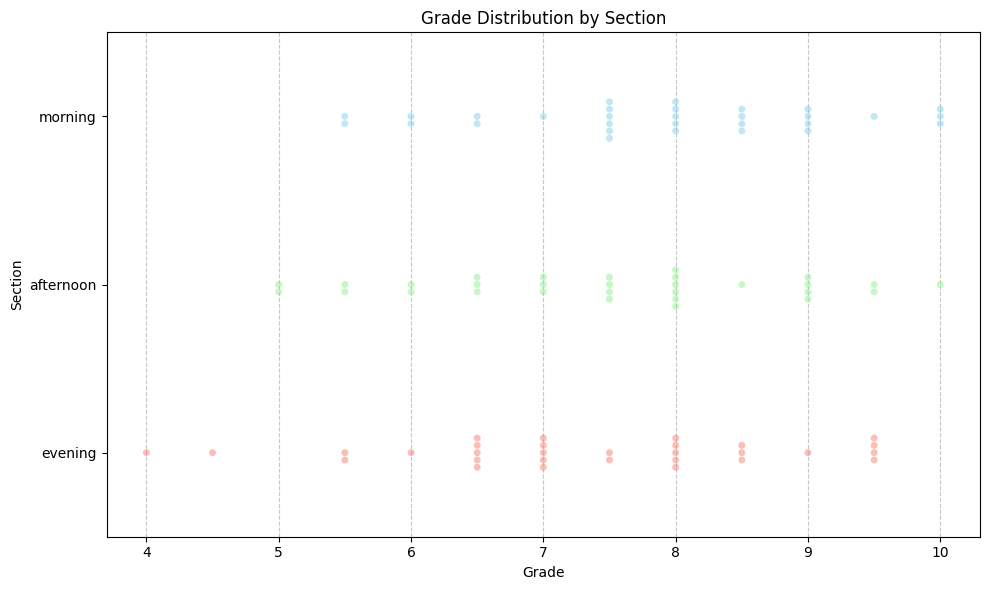

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.swarmplot(x='Score', y='Time of Day', data=test_scores_melted,
              alpha=0.5, palette={'morning': 'skyblue', 'afternoon': 'lightgreen', 'evening': 'salmon'}, hue='Time of Day', legend=False, size=5)

plt.title('Grade Distribution by Section')
plt.xlabel('Grade')
plt.ylabel('Section')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Comparing Morning and Evening Groups

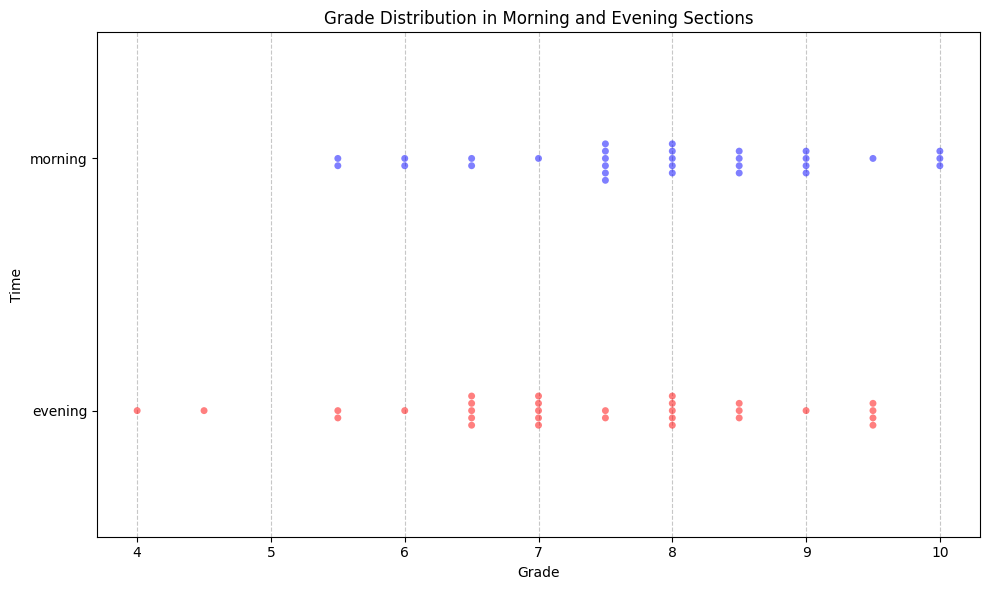

In [14]:
morning_evening_scores = test_scores_melted[test_scores_melted['Time of Day'].isin(['morning', 'evening'])].copy()

plt.figure(figsize=(10, 6))
sns.swarmplot(x='Score', y='Time of Day', data=morning_evening_scores,
              alpha=0.5, palette={'morning': 'blue', 'evening': 'red'}, hue='Time of Day', legend=False, size=5)

plt.title('Grade Distribution in Morning and Evening Sections')
plt.xlabel('Grade')
plt.ylabel('Time')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Boxplot

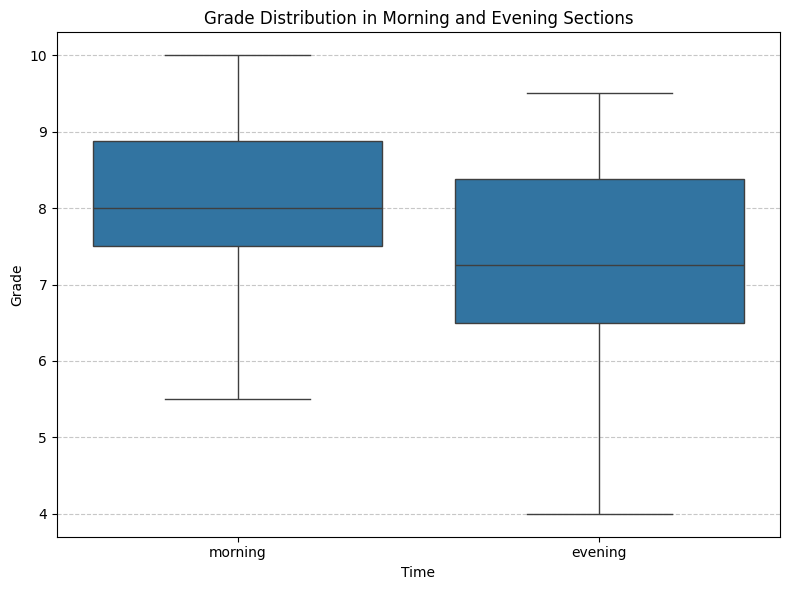

In [15]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Time of Day', y='Score', data=morning_evening_scores, legend=False)
plt.title('Grade Distribution in Morning and Evening Sections')
plt.xlabel('Time')
plt.ylabel('Grade')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Standard deviation of morning scores: 1.27
Standard deviation of evening scores: 1.43
Estimated standard deviation of the difference (standard error): 0.35
t-statistic: 1.62
Degrees of freedom: 58
Right-tail p-value: 0.055


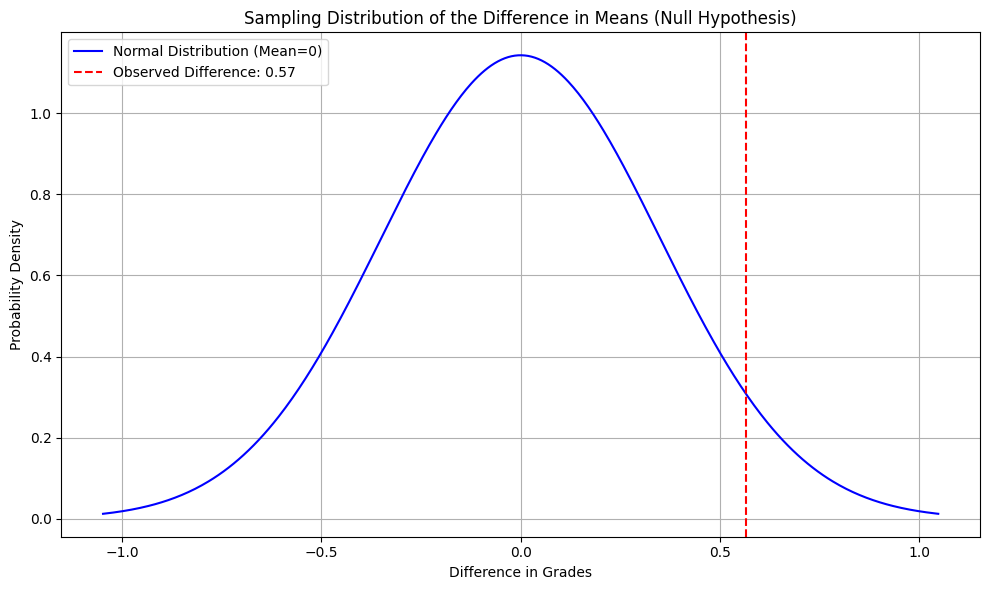

In [17]:
from scipy.stats import norm, t
import numpy as np
import matplotlib.pyplot as plt

# Extract scores for the groups from the melted dataframe
morning_scores = morning_evening_scores[morning_evening_scores['Time of Day'] == 'morning']['Score']
evening_scores = morning_evening_scores[morning_evening_scores['Time of Day'] == 'evening']['Score']

std_morning = np.std(morning_scores, ddof=1)
std_evening = np.std(evening_scores, ddof=1)

n_morning = len(morning_scores)
n_evening = len(evening_scores)

std_dev_of_difference = np.sqrt((std_morning**2 / n_morning) + (std_evening**2 / n_evening))

print(f"Standard deviation of morning scores: {std_morning:.2f}")
print(f"Standard deviation of evening scores: {std_evening:.2f}")
print(f"Estimated standard deviation of the difference (standard error): {std_dev_of_difference:.2f}")

t_statistic = difference / std_dev_of_difference
degrees_of_freedom = n_morning + n_evening - 2
p_value = t.sf(t_statistic, degrees_of_freedom)

print(f"t-statistic: {t_statistic:.2f}")
print(f"Degrees of freedom: {degrees_of_freedom}")
print(f"Right-tail p-value: {p_value:.3f}")

plt.figure(figsize=(10, 6))
x = np.linspace(-3 * std_dev_of_difference, 3 * std_dev_of_difference, 500)
plt.plot(x, norm.pdf(x, 0, std_dev_of_difference), color='blue', label='Normal Distribution (Mean=0)')
plt.axvline(difference, color='red', linestyle='--', label=f'Observed Difference: {difference:.2f}')
plt.title('Sampling Distribution of the Difference in Means (Null Hypothesis)')
plt.xlabel('Difference in Grades')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [18]:
combined_scores_single_draw = np.concatenate((morning_scores, evening_scores))

print("Scores in one pile:")
display(pd.Series(combined_scores_single_draw).to_frame(name='Score'))

np.random.shuffle(combined_scores_single_draw)

len_half = len(combined_scores_single_draw) // 2
group_a_single_draw = combined_scores_single_draw[:len_half]
group_b_single_draw = combined_scores_single_draw[len_half:]

display_df = pd.DataFrame({
    'A': pd.Series(group_a_single_draw),
    'B': pd.Series(group_b_single_draw)
})

print("\nGrades in random groups A and B:")
display(display_df)

mean_a_single_draw = np.mean(group_a_single_draw)
mean_b_single_draw = np.mean(group_b_single_draw)
difference_single_draw = mean_a_single_draw - mean_b_single_draw

print(f"\nGroup A mean: {mean_a_single_draw:.2f}")
print(f"Group B mean: {mean_b_single_draw:.2f}")
print(f"Difference of means (A - B): {difference_single_draw:.2f}")

Scores in one pile:


,Score
0,9.0
1,8.0
2,9.0
3,10.0
4,8.0
5,8.0
6,10.0
7,9.5
8,7.5
9,9.0



Grades in random groups A and B:


,A,B
0,5.5,9.0
1,6.0,8.0
2,9.5,9.0
3,7.5,8.5
4,9.5,7.0
5,8.5,7.0
6,8.0,8.0
7,7.5,5.5
8,8.0,10.0
9,6.5,7.0



Group A mean: 7.53
Group B mean: 7.73
Difference of means (A - B): -0.20


# Repeated Comparison (Permutation Test)

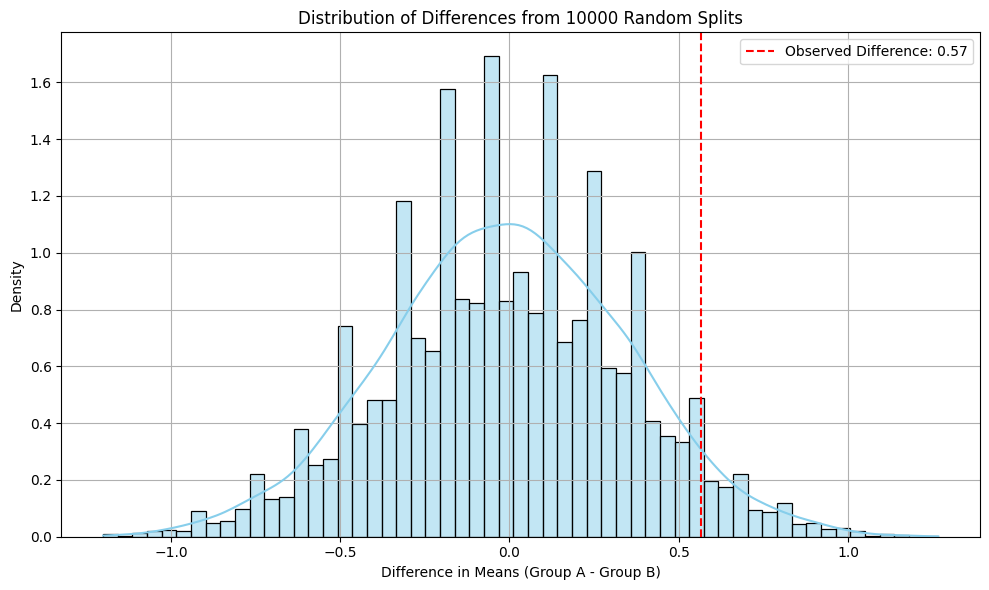

Observed difference (morning - evening): 0.57
Empirical p-value (two-tailed): 0.122
Empirical p-value (right-tail): 0.057


In [37]:
combined_scores = np.concatenate((morning_scores, evening_scores))
num_simulations = 10000
random_differences = []

for _ in range(num_simulations):
    np.random.shuffle(combined_scores)
    group_a = combined_scores[:len(combined_scores)//2]
    group_b = combined_scores[len(combined_scores)//2:]
    diff = np.mean(group_a) - np.mean(group_b)
    random_differences.append(diff)

plt.figure(figsize=(10, 6))
sns.histplot(random_differences, kde=True, color='skyblue', stat='density')
plt.axvline(difference, color='red', linestyle='--', label=f'Observed Difference: {difference:.2f}')
plt.title(f'Distribution of Differences from {num_simulations} Random Splits')
plt.xlabel('Difference in Means (Group A - Group B)')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

empirical_p_value = np.sum(np.abs(random_differences) >= np.abs(difference)) / num_simulations
print(f"Observed difference (morning - evening): {difference:.2f}")
print(f"Empirical p-value (two-tailed): {empirical_p_value:.3f}")

empirical_p_value_right_tail = np.sum(random_differences >= difference) / num_simulations
print(f"Empirical p-value (right-tail): {empirical_p_value_right_tail:.3f}")

# Correct Multi-Group Comparison: Analysis of Variance (ANOVA)

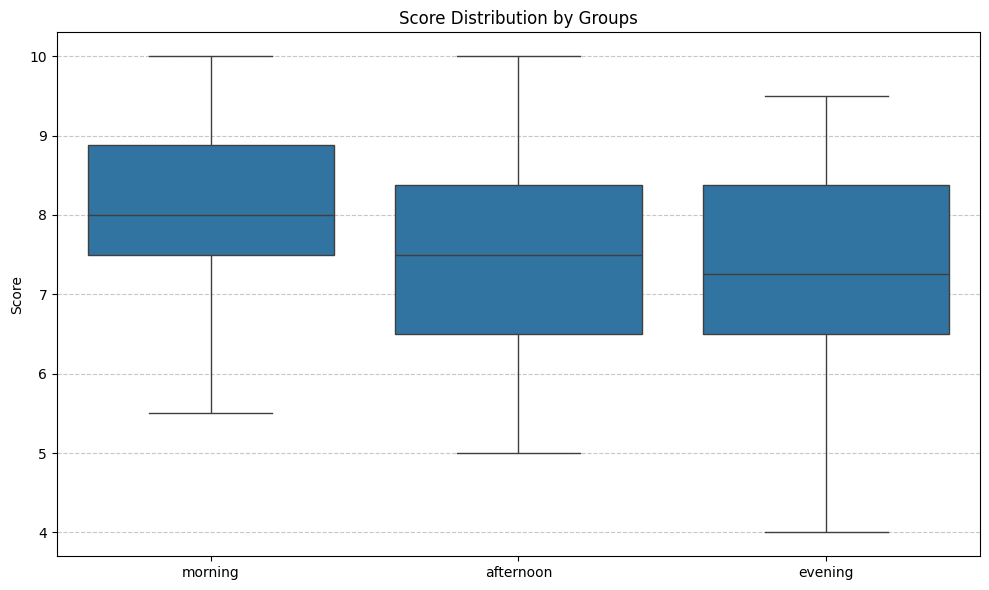

In [38]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Time of Day', y='Score', data=test_scores_melted, legend=False)
plt.title('Score Distribution by Groups')
plt.xlabel('')
plt.ylabel('Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [39]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

test_scores_melted['Time of Day'] = test_scores_melted['Time of Day'].astype('category')

model = ols('Score ~ C(Q("Time of Day"))', data=test_scores_melted).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
anova_table = anova_table.rename(index={'C(Q("Time of Day"))': 'Time of Day'})

print("\nOne-Way ANOVA Summary Table:")
display(anova_table)

p_value = anova_table['PR(>F)'].iloc[0]

if p_value < 0.05:
    print("\nSince the p-value (< 0.05) is statistically significant, we can reject the null hypothesis. This means there are statistically significant differences between the average scores in the morning, afternoon, and evening groups.")
else:
    print("\nSince the p-value (>= 0.05) is not statistically significant, we cannot reject the null hypothesis. This means there is insufficient evidence to claim statistically significant differences between the average scores in the morning, afternoon, and evening groups.")


One-Way ANOVA Summary Table:


,sum_sq,df,F,PR(>F)
Time of Day,5.172222,2.0,1.400799,0.251901
Residual,160.616667,87.0,NaN,NaN



Since the p-value (>= 0.05) is not statistically significant, we cannot reject the null hypothesis. This means there is insufficient evidence to claim statistically significant differences between the average scores in the morning, afternoon, and evening groups.


# Simpson's Paradox and Two-Way ANOVA

In [4]:
import pandas as pd

# Define the path to the CSV file on GitHub
file_path2 = 'https://raw.githubusercontent.com/ust-buan-640/buan-640-notebooks/main/data/two_way_anova_simpson.csv'

# Load the CSV file
test_majors = pd.read_csv(file_path2)

# Translate column names to English
test_majors.rename(columns={
    'time_of_day': 'group',
    'score': 'score',
    'major': 'major'
}, inplace=True)

# Define the desired order
desired_group_order = ['morning', 'afternoon', 'evening']

# Display the top of the dataset
display(test_majors.head())

,group,score,major
0,afternoon,5.0,entrepreneurship
1,afternoon,5.0,finance
2,afternoon,5.5,entrepreneurship
3,afternoon,5.5,finance
4,afternoon,6.0,entrepreneurship


In [5]:
average_scores_by_time_of_day = test_majors.groupby('group', observed=False)['score'].mean().reset_index()
average_scores_by_time_of_day.columns = ['group', 'Average Score']
display(average_scores_by_time_of_day)

,group,Average Score
0,afternoon,7.500000
1,evening,7.350000
2,morning,7.916667


In [6]:
import pandas as pd
import numpy as np

two_way_table = pd.pivot_table(test_majors, values='score', index='group', columns='major', aggfunc='mean', observed=False)

print('\nTwo-Way table of average scores by group and major:')
display(np.round(two_way_table, 2))


Two-Way table of average scores by group and major:


major,entrepreneurship,finance
group,,
afternoon,7.43,7.57
evening,6.20,8.50
morning,8.90,6.93


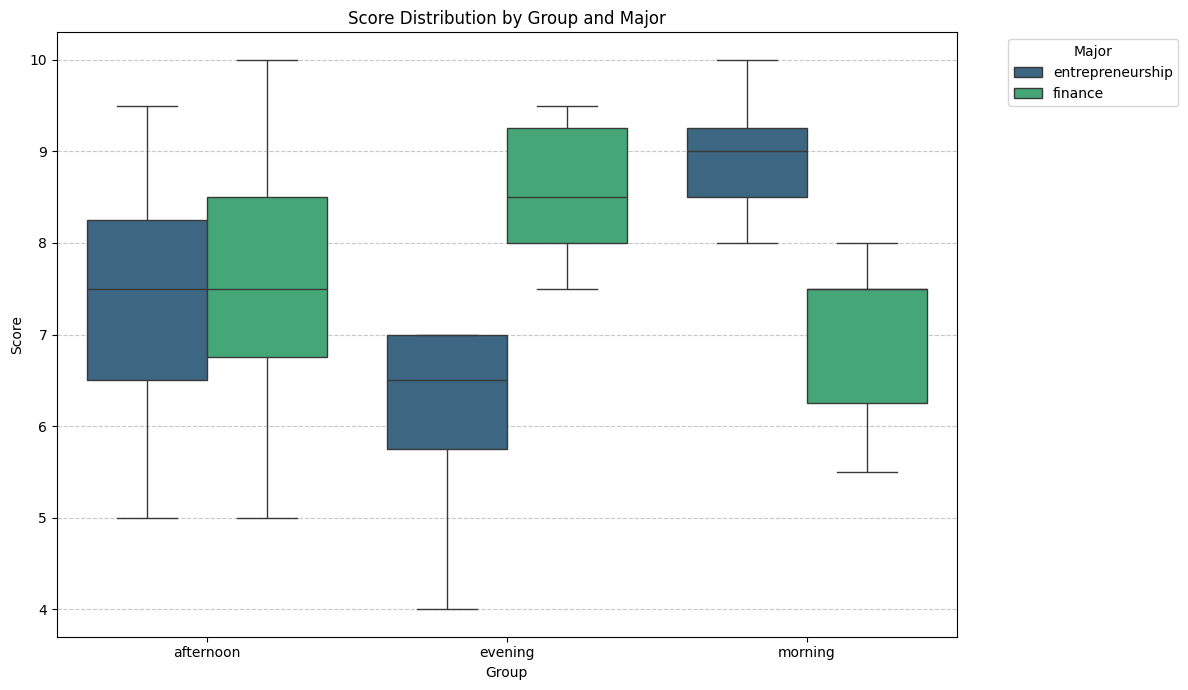

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.boxplot(x='group', y='score', hue='major', data=test_majors, palette='viridis')
plt.title('Score Distribution by Group and Major')
plt.xlabel('Group')
plt.ylabel('Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Major', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [20]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

test_majors['group'] = test_majors['group'].astype('category')
test_majors['major'] = test_majors['major'].astype('category')

model_two_way = ols('score ~ C(group) + C(major) + C(group):C(major)', data=test_majors).fit()
anova_table_two_way = sm.stats.anova_lm(model_two_way, typ=2)

print('\nTwo-Way ANOVA Results Table:')
display(anova_table_two_way)


Two-Way ANOVA Results Table:


,sum_sq,df,F,PR(>F)
C(group),5.172222,2.0,2.366376,1.000470e-01
C(major),0.544444,1.0,0.498184,4.822519e-01
C(group):C(major),68.272222,2.0,31.235657,7.213096e-11
Residual,91.800000,84.0,NaN,NaN


# Experimental Design

Controlled and random distribution of objects among groups.
- Key point: the variable of interest and the fact of belonging to a group must be independent.